In [8]:
import sys
sys.path.extend(['/home/zhaoy/packages/Pyramid']) 
#sys.path.extend(['/Users/fzheng/SkyDrive/Codes/Python/Pyramid']) # where Pyramid situates
print('Python %s on %s' % (sys.version, sys.platform))


import cv2
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt 
%matplotlib inline
import hyperspy.api as hs
import pyramid as pr
import os
from tqdm import tqdm_notebook as tqdm
from scipy.ndimage import gaussian_filter, rotate, binary_dilation, shift
pr.plottools.pretty_plots()
import h5py

Python 3.5.6 |Anaconda, Inc.| (default, Jun  4 2021, 13:57:47) 
[GCC 7.5.0] on linux


创建方形MASK，遮挡因Phase旋转而带出的区域

Mask 形状: (206, 206)
Mask 中的唯一值: [0 1]


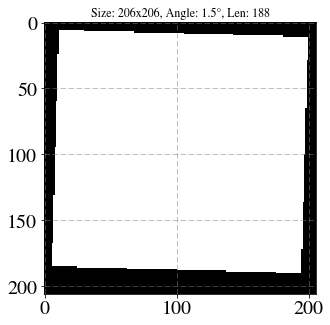

In [9]:
def create_rotated_mask(
    img_shape=(206, 206), 
    center=(103, 103), 
    length=180, 
    width=20, 
    angle=30):
    """
    生成一个包含旋转矩形的二值Mask。
    
    参数:
    - img_shape: 图片尺寸 (H, W)
    - center: 旋转中心 (x, y)
    - length: 矩形长度 (主轴)
    - width: 矩形宽度 (如果你需要一条线，可以将此值设为 1 或 2)
    - angle: 逆时针旋转角度 (度)
    
    返回:
    - mask: 0和1组成的numpy数组
    """
    # 1. 创建全黑背景 (全0)
    mask = np.zeros(img_shape, dtype=np.uint8)
    
    # 2. 定义旋转矩形的数据结构
    # OpenCV格式: ((中心x, 中心y), (宽, 高), 角度)
    # 注意：在OpenCV中，角度通常是逆时针方向
    rect = (center, (length, width), angle)
    
    # 3. 计算矩形的四个角点
    box = cv2.boxPoints(rect)
    box = np.int0(box) # 转换为整数坐标
    
    # 4. 在Mask上填充这个矩形区域，数值设为 1
    # color=1 表示填充值为1, thickness=-1 表示实心填充
    cv2.drawContours(mask, [box], 0, 1, -1)
    
    return mask

H, W = 206, 206
center_x, center_y = 103, 98    # 左加右减，上加下减
line_len = 188
line_width = 178  # 这里设置线条/矩形的粗细/宽度，你可以调节
rotate_angle = 1.5 

rect_mask = create_rotated_mask(
    img_shape=(H, W),
    center=(center_x, center_y),
    length=line_len,
    width=line_width,
    angle=rotate_angle
)

print("Mask 形状: {}".format(rect_mask.shape))
print("Mask 中的唯一值: {}".format(np.unique(rect_mask))) # 应该只包含 0 和 1

plt.figure(figsize=(5, 5))
plt.imshow(rect_mask, cmap='gray')
plt.title("Size: {}x{}, Angle: {}°, Len: {}".format(H, W, rotate_angle, line_len))
plt.grid(True, which='both', color='gray', linestyle='--', linewidth=0.5)
plt.show()

将方形MASK和Phase对齐，切除无关边界

pm shape: (194, 204)
填充后 phase 形状: (206, 206)
pm shape: (194, 204)
填充后 phase 形状: (206, 206)
pm shape: (194, 204)
填充后 phase 形状: (206, 206)
pm shape: (194, 204)
填充后 phase 形状: (206, 206)
pm shape: (194, 204)
填充后 phase 形状: (206, 206)
pm shape: (194, 204)
填充后 phase 形状: (206, 206)
pm shape: (194, 204)
填充后 phase 形状: (206, 206)
pm shape: (194, 204)
填充后 phase 形状: (206, 206)


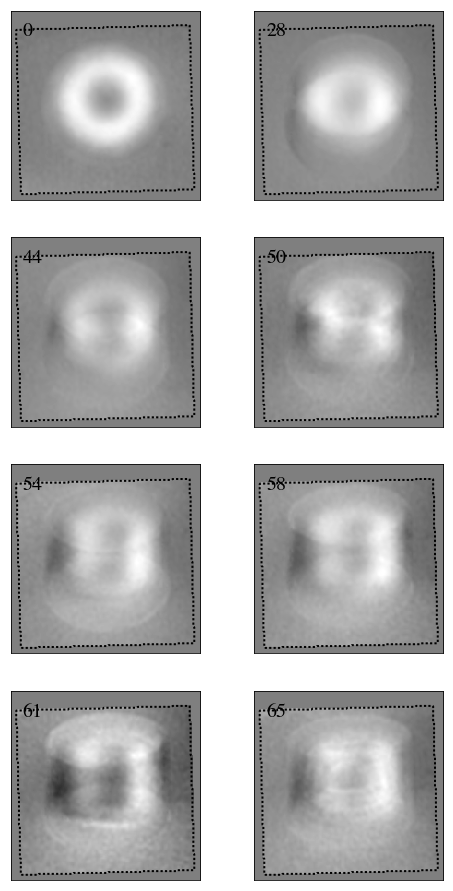

In [10]:
angles = [0,28,44,50,54,58,61,65]
fig = plt.figure(figsize=(8,16))
ax = {}
magdata = hs.load('/home/zhaoy/studio/target-skyrmion/dataset/dm3_refin/refin_Mag_alg_roted-aligned (Manually Aligned)_t_f_off.dm3')
mipdata = hs.load('/home/zhaoy/studio/target-skyrmion/dataset/dm3_refin/refine_MIP_alg_roted-aligned_f.dm3')

 # 相位平移，mask不动
l = 0  # 纵向平移量（例如：2表示向下移动2像素）
h = 0  # 横向平移量（例如：-2表示向右移动2像素）
phasemaps = []
for i, angle in enumerate(angles):
    tilt = angle
    maskdata = rect_mask#[i]
    pm = magdata.inav[i].data
    print("pm shape: {}".format(pm.shape))
    padded_pm = np.pad(pm, 
                        pad_width=((6, 6), (1, 1)),  # (y_top, y_bottom), (x_left, x_right)
                        mode='edge')  # 边缘值填充
    print("填充后 phase 形状: {}".format(padded_pm.shape))
    
    vert_pm = padded_pm.copy() # 如果 l=0，直接保持不变
    if l != 0:
        vert_pm = np.zeros_like(padded_pm) # 初始化全0
        if l > 0: 
            vert_pm[:-l, :] = padded_pm[l:, :]
            vert_pm[-l:, :] = padded_pm[-l:, :] # 边缘填充
        elif l < 0:  
            l_abs = abs(l)
            vert_pm[l_abs:, :] = padded_pm[:-l_abs, :]
            vert_pm[:l_abs, :] = padded_pm[:l_abs, :] # 边缘填充
    shifted_pm = vert_pm.copy() 
    if h != 0:
        shifted_pm = np.zeros_like(vert_pm) # 初始化全0
        if h > 0:  
            shifted_pm[:, :-h] = vert_pm[:, h:]  # <--- 注意这里读的是 vert_pm
            shifted_pm[:, -h:] = vert_pm[:, -h:]
        elif h < 0:  
            h_abs = abs(h)
            shifted_pm[:, h_abs:] = vert_pm[:, :-h_abs] # <--- 注意这里读的是 vert_pm
            shifted_pm[:, :h_abs] = vert_pm[:, :h_abs]
    pm = shifted_pm
    mask = maskdata#.data

    phasemaps.append(pr.PhaseMap(a=1, phase=pm*mask, mask=mask))
    ax[i+1] = fig.add_subplot(4, 2, i+1, aspect='equal')
    ax[i+1].get_xaxis().set_visible(False)
    ax[i+1].get_yaxis().set_visible(False)
    phasemaps[i].plot_phase(axis=ax[i+1],scalebar=False,note="{}".format(np.abs(tilt)),cbar=False,cmap='gray',show_mask=True)

投影3D MASK，得到系列角度

In [11]:
def process_and_project_mask(file_path, threshold=0.5, rotation_angle=0, dilation_iter=1):
    try:
        s = hs.load(file_path)
        print("原始数据形状: {}".format(s.data.shape))
    except Exception as e:
        print("❌ 读取失败: {}".format(e))
        return

    # (Z, Y, X) -> (X, Y, Z) 绕 X 轴旋转
    data = s.data.transpose((2, 1, 0))
    print("转置数据形状: {} (X, Y, Z)".format(data.shape))

    mask = data > threshold
    mask_int = mask.astype(np.int8)

    print("绕中心 (X轴) 旋转 {} 度 ...".format(rotation_angle))
    rotated_mask = rotate(
        mask_int, 
        angle=-1*rotation_angle, 
        axes=(1, 2), 
        reshape=False, 
        order=0, 
        mode='constant', 
        cval=0
    )
    
    # Z 方向投影 ---
    projection = np.max(rotated_mask, axis=2)
    projection = np.rot90(projection, k=1)  # k=1表示逆时针90度
    if dilation_iter > 0:
        print("正在执行形态学膨胀，迭代次数: {} ...".format(dilation_iter))
        projection = binary_dilation(projection, iterations=dilation_iter) 
        projection = projection.astype(np.float32) 
    print("投影完成，投影图形状: {} (X, Y)".format(projection.shape))
    
    # 创建新的 Signal2D
    projection_final = projection.astype(np.float32)
    s_out = hs.signals.Signal2D(projection_final)
    
    # 6.2 迁移坐标轴校准 (Axes Manager)
    # s_out (X, Y) 对应原始数据的 (X, Y) -> 即原始 s 的 Axis 2 和 Axis 1
    
    # 获取原始轴对象 (假设原始 s.axes_manager 是 [AxisZ, AxisY, AxisX])
    orig_y = s.axes_manager[1]
    orig_x = s.axes_manager[2]
    
    # 设置新信号的轴
    s_out.axes_manager[0].name = orig_x.name
    s_out.axes_manager[0].scale = orig_x.scale
    s_out.axes_manager[0].offset = orig_x.offset
    s_out.axes_manager[0].units = orig_x.units

    s_out.axes_manager[1].name = orig_y.name
    s_out.axes_manager[1].scale = orig_y.scale
    s_out.axes_manager[1].offset = orig_y.offset
    s_out.axes_manager[1].units = orig_y.units
    return s_out

if __name__ == "__main__":
    input_path = '/home/zhaoy/studio/target-skyrmion/dataset/dm3_refin/3dmask.dm3'
    
    rotation_angles = [0, 28, 44, 50, 54, 58, 61, 65.2]
    geo_masks = []
    for rotation_angle in rotation_angles:
        mask = process_and_project_mask(input_path, threshold=0.5, rotation_angle=rotation_angle)
        geo_masks.append(mask)

原始数据形状: (206, 206, 206)
转置数据形状: (206, 206, 206) (X, Y, Z)
绕中心 (X轴) 旋转 0 度 ...
正在执行形态学膨胀，迭代次数: 1 ...
投影完成，投影图形状: (206, 206) (X, Y)
原始数据形状: (206, 206, 206)
转置数据形状: (206, 206, 206) (X, Y, Z)
绕中心 (X轴) 旋转 28 度 ...
正在执行形态学膨胀，迭代次数: 1 ...
投影完成，投影图形状: (206, 206) (X, Y)
原始数据形状: (206, 206, 206)
转置数据形状: (206, 206, 206) (X, Y, Z)
绕中心 (X轴) 旋转 44 度 ...
正在执行形态学膨胀，迭代次数: 1 ...
投影完成，投影图形状: (206, 206) (X, Y)
原始数据形状: (206, 206, 206)
转置数据形状: (206, 206, 206) (X, Y, Z)
绕中心 (X轴) 旋转 50 度 ...
正在执行形态学膨胀，迭代次数: 1 ...
投影完成，投影图形状: (206, 206) (X, Y)
原始数据形状: (206, 206, 206)
转置数据形状: (206, 206, 206) (X, Y, Z)
绕中心 (X轴) 旋转 54 度 ...
正在执行形态学膨胀，迭代次数: 1 ...
投影完成，投影图形状: (206, 206) (X, Y)
原始数据形状: (206, 206, 206)
转置数据形状: (206, 206, 206) (X, Y, Z)
绕中心 (X轴) 旋转 58 度 ...
正在执行形态学膨胀，迭代次数: 1 ...
投影完成，投影图形状: (206, 206) (X, Y)
原始数据形状: (206, 206, 206)
转置数据形状: (206, 206, 206) (X, Y, Z)
绕中心 (X轴) 旋转 61 度 ...
正在执行形态学膨胀，迭代次数: 1 ...
投影完成，投影图形状: (206, 206) (X, Y)
原始数据形状: (206, 206, 206)
转置数据形状: (206, 206, 206) (X, Y, Z)
绕中心 (X轴) 旋转 65.2 度 ...
正在执

将裁剪后的Phase和几何形态MASK对齐，裁剪出样品周围区域相位

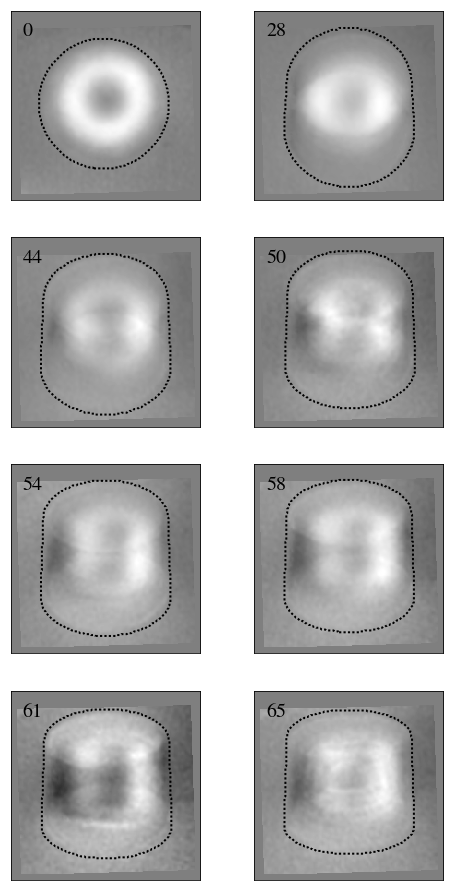

In [12]:
angles = [0, 28, 44, 50, 54, 58, 61, 65]
fig2 = plt.figure(figsize=(8,16))
ax2 = {}
phasemaps2 = []

# l > 0 向下, l < 0 向上
# h > 0 向右, h < 0 向左
for i in range (len(angles)):
    if i == 7:
        l = 5
        h = 0  
    elif i == 6:
        l = 3
        h = 1
    elif i == 5:
        l = 4
        h = 0
    elif i ==4:
        l = 2
        h = 0
    elif i == 3:
        l = 4
        h = 1
    elif i == 2:
        l = -1
        h = 0
    elif i == 1:
        l = -1
        h = 0
    elif i == 0:
        l = 2
        h = -2

    pm = phasemaps[i].phase  # 已经被方形mask裁剪好
    maskdata = geo_masks[i] # 3d mask投影

    tilt = angles[i]

    shifted_maskdata = shift(maskdata, shift=[l, h], order=0, mode='constant', cval=0)

    maskdata = shifted_maskdata
    pm = phasemaps[i].phase

    phasemaps2.append(pr.PhaseMap(a=1, phase=pm, mask=maskdata))
    ax2[i+1] = fig2.add_subplot(4, 2, i+1, aspect='equal')
    ax2[i+1].get_xaxis().set_visible(False)
    ax2[i+1].get_yaxis().set_visible(False)
    phasemaps2[i].plot_phase(axis=ax2[i+1],scalebar=False,note="{}".format(np.abs(tilt)),cbar=False,show_mask=True,cmap='gray')


In [13]:
# fig3 = plt.figure(figsize=(8,16))
# ax3 = {}
# phasemaps3 = []

# for i in range(len(angles)):
#     offset = np.angle(np.mean(np.exp(1j * phasemaps2[i].phase)))
#     print("计算得到的真空区域背景均值 (rad): {:.4f}".format(offset))
#     pm_refin = phasemaps[i].phase + offset
#     pm_refin = np.angle(np.exp(1j * pm_refin))
#     pm3 = pr.PhaseMap(a=1, phase=pm_refin, mask=phasemaps2[i].mask)
#     phasemaps3.append(pm3)
#     print(np.min(phasemaps[i].phase), np.max(phasemaps[i].phase))
#     print(np.min(phasemaps3[i].phase), np.max(phasemaps3[i].phase))
#     ax3[i+1] = fig3.add_subplot(4, 2, i+1, aspect='equal')
#     ax3[i+1].get_xaxis().set_visible(False)
#     ax3[i+1].get_yaxis().set_visible(False)
#     phasemaps3[i].plot_phase(axis=ax3[i+1],scalebar=False,note="{}".format(angles[i]),cbar=False,show_mask=True)


In [14]:
data_to_save = []
for i in range(len(angles)):
    save_item = {
            'data': phasemaps2[i].phase,                # 相位 (numpy array)
            'mask': phasemaps2[i].mask,              # 掩膜 (numpy array)
            'alpha': angles[i],    
            'beta': 0.0,             
            'gamma': 0.0              
        }
    data_to_save.append(save_item)
    print("已添加 Angle {} 的数据到保存列表。".format(angles[i]))

    output_path = 'phasemap_{:g}.pth'.format(angles[i])
    torch.save(data_to_save, output_path)
    print("所有数据已保存至: {}".format(output_path))

已添加 Angle 0 的数据到保存列表。
所有数据已保存至: phasemap_0.pth
已添加 Angle 28 的数据到保存列表。
所有数据已保存至: phasemap_28.pth
已添加 Angle 44 的数据到保存列表。
所有数据已保存至: phasemap_44.pth
已添加 Angle 50 的数据到保存列表。
所有数据已保存至: phasemap_50.pth
已添加 Angle 54 的数据到保存列表。
所有数据已保存至: phasemap_54.pth
已添加 Angle 58 的数据到保存列表。
所有数据已保存至: phasemap_58.pth
已添加 Angle 61 的数据到保存列表。
所有数据已保存至: phasemap_61.pth
已添加 Angle 65 的数据到保存列表。
所有数据已保存至: phasemap_65.pth
